In [5]:
import os 
from dotenv import load_dotenv

In [6]:
load_dotenv()

True

In [7]:
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [8]:
from langchain_groq import ChatGroq

model=ChatGroq(model="openai/gpt-oss-120b")
model.invoke("hello")


c:\agentic ai\llm\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user just says "hello". We should respond politely. No special instructions.'}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 72, 'total_tokens': 107, 'completion_time': 0.072036434, 'completion_tokens_details': {'reasoning_tokens': 17}, 'prompt_time': 0.002884638, 'prompt_tokens_details': None, 'queue_time': 0.051551711, 'total_time': 0.074921072}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_bc9a6c9b5f', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dc45c-c84a-7982-be21-fb7331ca09aa-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 35, 'total_tokens': 107, 'output_token_details': {'reasoning': 17}})

In [9]:
from langchain_core.messages import HumanMessage
model.invoke([HumanMessage(content="Hi my name is prem and i am data analyst freelancer")])

AIMessage(content='Hello Prem! 👋 Nice to meet you. How can I assist you today? Whether you need help with data analysis techniques, visualization ideas, Python/R code, or anything else related to your freelance projects, just let me know!', additional_kwargs={'reasoning_content': 'The user says "Hi my name is prem and i am data analyst freelancer". Likely they are greeting and introducing themselves. The assistant should respond politely, perhaps ask how can help. No disallowed content. So respond friendly, ask what they need.'}, response_metadata={'token_usage': {'completion_tokens': 108, 'prompt_tokens': 82, 'total_tokens': 190, 'completion_time': 0.224394169, 'completion_tokens_details': {'reasoning_tokens': 52}, 'prompt_time': 0.004517981, 'prompt_tokens_details': None, 'queue_time': 0.051420848, 'total_time': 0.22891215}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_626f3fc5e0', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provid

In [10]:
from langchain_core.messages import AIMessage

model.invoke(
    [
     HumanMessage(content="Hi, my name is prem and i am a data analyst freelancer"),
     AIMessage(content="Hi Prem! 👋 Great to meet you. As a data‑analysis freelancer, you probably juggle a lot of projects, tools, and client expectations. How can I help you today? Whether you’re looking for advice on a specific analysis, tips on visualisation, automation ideas, or anything else, just let me know!"),
     HumanMessage(content="Hey, what's my name and what do i do")
     ]
)


AIMessage(content='You introduced yourself as **Prem**, and you work as a **freelance data analyst**.', additional_kwargs={'reasoning_content': 'The user asks: "Hey, what\'s my name and what do i do". The user previously said: "Hi, my name is prem and i am a data analyst freelancer". So answer: Prem, data analyst freelancer. Provide friendly response.'}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 171, 'total_tokens': 250, 'completion_time': 0.164148603, 'completion_tokens_details': {'reasoning_tokens': 50}, 'prompt_time': 0.006769989, 'prompt_tokens_details': None, 'queue_time': 0.051766131, 'total_time': 0.170918592}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_bc9a6c9b5f', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dc45c-ccf8-7cd3-8968-752c710dec67-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 171, 'output_tokens': 79, 'total_tokens':

In [11]:
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.chat_history import BaseChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory

store={}

def get_session_history(session_id:str)-> BaseChatMessageHistory:
    if session_id not in store:
        store[session_id]=ChatMessageHistory()
        
    return store[session_id]

In [12]:
with_message_history=RunnableWithMessageHistory(model,get_session_history)
with_message_history

RunnableWithMessageHistory(bound=RunnableBinding(bound=RunnableBinding(bound=RunnableLambda(_enter_history), kwargs={}, config={'run_name': 'load_history'}, config_factories=[])
| RunnableBinding(bound=RunnableLambda(_call_runnable_sync), kwargs={}, config={'run_name': 'check_sync_or_async'}, config_factories=[]), kwargs={}, config={'run_name': 'RunnableWithMessageHistory'}, config_factories=[]), kwargs={}, config={}, config_factories=[], get_session_history=<function get_session_history at 0x000002A913987910>, history_factory_config=[ConfigurableFieldSpec(id='session_id', annotation=<class 'str'>, name='Session ID', description='Unique identifier for a session.', default='', is_shared=True, dependencies=None)])

In [13]:
config={"configurable":{"session_id":"prem"}}

response=with_message_history.invoke(
    [HumanMessage(content="Hi, my name is prem and i am a data analyst freelancer")],
    config=config
    
    
)
response

AIMessage(content='Hello Prem! 👋\n\nGreat to meet a fellow data‑analysis enthusiast. How’s the freelance life treating you? If there’s anything you’d like to chat about—whether it’s tools, techniques, finding new clients, tackling a tricky dataset, or just sharing experiences—feel free to let me know. I’m happy to help!', additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The user introduced themselves. Likely they want a response. We can greet, ask about their work, maybe offer help. No disallowed content. So respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 121, 'prompt_tokens': 84, 'total_tokens': 205, 'completion_time': 0.257025496, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.014112058, 'prompt_tokens_details': None, 'queue_time': 0.055521595, 'total_time': 0.271137554}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_626f3fc5e0', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprob

In [14]:
response=with_message_history.invoke(
    [HumanMessage(content="what is my name")],
    config=config
)
response

AIMessage(content='You mentioned that your name is **Prem**.', additional_kwargs={'reasoning_content': 'User asks "what is my name". We have user introduction: "Hi, my name is prem and i am a data analyst freelancer". So answer: Prem. Should respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 167, 'total_tokens': 224, 'completion_time': 0.124244818, 'completion_tokens_details': {'reasoning_tokens': 38}, 'prompt_time': 0.013893654, 'prompt_tokens_details': None, 'queue_time': 0.061965265, 'total_time': 0.138138472}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_d81b3304b3', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dc45c-d10d-7f92-8963-1d59db364155-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 167, 'output_tokens': 57, 'total_tokens': 224, 'output_token_details': {'reasoning': 38}})

In [15]:
get_session_history("prem")

InMemoryChatMessageHistory(messages=[HumanMessage(content='Hi, my name is prem and i am a data analyst freelancer', additional_kwargs={}, response_metadata={}), AIMessage(content='Hello Prem! 👋\n\nGreat to meet a fellow data‑analysis enthusiast. How’s the freelance life treating you? If there’s anything you’d like to chat about—whether it’s tools, techniques, finding new clients, tackling a tricky dataset, or just sharing experiences—feel free to let me know. I’m happy to help!', additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The user introduced themselves. Likely they want a response. We can greet, ask about their work, maybe offer help. No disallowed content. So respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 121, 'prompt_tokens': 84, 'total_tokens': 205, 'completion_time': 0.257025496, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.014112058, 'prompt_tokens_details': None, 'queue_time': 0.055521595, 'tota

In [16]:
config1={"configurable":{"session_id":"Krish"}}
response=with_message_history.invoke(
    [HumanMessage(content="My name is krish , i'm data scientist")],
    config=config1
)
response

AIMessage(content='Nice to meet you, Krish! 🎉 As a data scientist, you’re probably juggling everything from data wrangling to model deployment. How can I help you today? Whether you’re looking for advice on a specific algorithm, tips on feature engineering, help with a coding problem, or just want to chat about the latest trends in AI, I’m here for you. 🚀', additional_kwargs={'reasoning_content': 'The user says: "My name is krish , i\'m data scientist". Likely they are introducing themselves. The assistant should respond politely, maybe ask how can help, maybe discuss data science topics. Should follow guidelines: be friendly, ask how can assist. Should not reveal system messages. Should respond in a conversational manner.'}, response_metadata={'token_usage': {'completion_tokens': 153, 'prompt_tokens': 80, 'total_tokens': 233, 'completion_time': 0.338072915, 'completion_tokens_details': {'reasoning_tokens': 66}, 'prompt_time': 0.003911983, 'prompt_tokens_details': None, 'queue_time': 0

In [17]:
get_session_history("Krish")

InMemoryChatMessageHistory(messages=[HumanMessage(content="My name is krish , i'm data scientist", additional_kwargs={}, response_metadata={}), AIMessage(content='Nice to meet you, Krish! 🎉 As a data scientist, you’re probably juggling everything from data wrangling to model deployment. How can I help you today? Whether you’re looking for advice on a specific algorithm, tips on feature engineering, help with a coding problem, or just want to chat about the latest trends in AI, I’m here for you. 🚀', additional_kwargs={'reasoning_content': 'The user says: "My name is krish , i\'m data scientist". Likely they are introducing themselves. The assistant should respond politely, maybe ask how can help, maybe discuss data science topics. Should follow guidelines: be friendly, ask how can assist. Should not reveal system messages. Should respond in a conversational manner.'}, response_metadata={'token_usage': {'completion_tokens': 153, 'prompt_tokens': 80, 'total_tokens': 233, 'completion_time'

### Prompt Template


In [18]:
from langchain_core.prompts import ChatPromptTemplate,MessagesPlaceholder

prompt=ChatPromptTemplate.from_messages(
    [
        ("system","You are a helpful assistant. Answer all the question to the best of your ability ."),
        MessagesPlaceholder(variable_name="messages")
    ]
)
chain=prompt|model

In [19]:
chain.invoke({"messages":[HumanMessage(content="Hi my name is prem")]})

AIMessage(content='Hello Prem! Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hi my name is prem". Probably greet them. We can ask how can help.'}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 96, 'total_tokens': 147, 'completion_time': 0.110006037, 'completion_tokens_details': {'reasoning_tokens': 27}, 'prompt_time': 0.01092665, 'prompt_tokens_details': None, 'queue_time': 0.05130862, 'total_time': 0.120932687}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_626f3fc5e0', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dc45c-d5db-7aa1-8b98-2a65ea99262a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 96, 'output_tokens': 51, 'total_tokens': 147, 'output_token_details': {'reasoning': 27}})

In [20]:
with_message_history=RunnableWithMessageHistory(chain,get_session_history)

In [21]:
config3={"configurable":{"session_id":"person3"}}

response=with_message_history.invoke(
    [HumanMessage(content="hi my name is unknown")],
    config=config3
)
response

AIMessage(content='Hello! Nice to meet you. Since you mentioned that your name is “unknown,” is there a nickname or a way you’d like me to address you? If you’d rather stay anonymous, that’s totally fine too—just let me know how I can help you today!', additional_kwargs={'reasoning_content': 'We need to respond. The user says "hi my name is unknown". Probably they want conversation. We can greet and ask name or continue. Since they said name is unknown, maybe we can ask how they want to be addressed. Be friendly.'}, response_metadata={'token_usage': {'completion_tokens': 116, 'prompt_tokens': 96, 'total_tokens': 212, 'completion_time': 0.246412997, 'completion_tokens_details': {'reasoning_tokens': 51}, 'prompt_time': 0.003554078, 'prompt_tokens_details': None, 'queue_time': 0.050803267, 'total_time': 0.249967075}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_a09bde29de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'},

In [22]:
response=with_message_history.invoke(
    [HumanMessage(content="what is my name")],
    config=config3
)
response

AIMessage(content='I don’t actually know your name—unless you’d like to tell me! If you share how you’d like to be addressed, I’ll be happy to use that going forward. 😊', additional_kwargs={'reasoning_content': 'User asks "what is my name". We don\'t know. Should respond that we don\'t know, ask for clarification.'}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 166, 'total_tokens': 237, 'completion_time': 0.153906684, 'completion_tokens_details': {'reasoning_tokens': 24}, 'prompt_time': 0.006361269, 'prompt_tokens_details': None, 'queue_time': 0.05121568, 'total_time': 0.160267953}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_d81b3304b3', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dc45c-d89d-73f3-9686-492aa2d2abc6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 166, 'output_tokens': 71, 'total_tokens': 237, 'output_token_details': {'reasoni

In [23]:
prompt=ChatPromptTemplate.from_messages(
    [
        ("system","You are a helpful assistant. Answer all the question to the best of your ability {language}."),
        MessagesPlaceholder(variable_name="messages")
    ]
)
chain=prompt|model

In [24]:
respone=chain.invoke({"messages":[HumanMessage(content="hi my name is prem")],"language":"Tamil"})
respone

AIMessage(content='வணக்கம் பிரெம்! நீங்கள் எப்படி இருக்கிறீர்கள்? உங்கள் கேள்விகள் அல்லது உதவி தேவைகள் இருந்தால், எப்போதும் சொல்லுங்கள். 😊', additional_kwargs={'reasoning_content': 'User says "hi my name is prem". The developer says answer all the question to the best of your ability Tamil. So respond in Tamil. Probably greet and ask something.'}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 97, 'total_tokens': 176, 'completion_time': 0.166461598, 'completion_tokens_details': {'reasoning_tokens': 36}, 'prompt_time': 0.014756949, 'prompt_tokens_details': None, 'queue_time': 0.059233861, 'total_time': 0.181218547}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_626f3fc5e0', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dc45c-da19-77b1-a82c-facca0bf6c42-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 97, 'output_tokens': 79, 'total_tokens': 176, 'ou

In [25]:
## Trimming the chat message which is bigger enough 

from langchain_core.messages import SystemMessage,trim_messages
from langchain_core.messages.utils import count_tokens_approximately

trimmer=trim_messages(
    max_tokens=100,
    strategy="last",
    token_counter=count_tokens_approximately,
    include_system=True,
    allow_partial=False,
    start_on="human"
)
messages=[
    SystemMessage(content="you're a good assistant"),
    HumanMessage(content="hi! I'm bob"),
    AIMessage(content="hi!"),
    HumanMessage(content="I like vanilla ice cream"),
    AIMessage(content="nice"),
    HumanMessage(content="what is 2 + 2"),
    AIMessage(content="4"),
    HumanMessage(content="thanks"),
    AIMessage(content="no problem!"),
    HumanMessage(content="having fun?"),
    AIMessage(content="yes!"),
    
]
# change the max_tokens value then trimmer might different by using msg history timmer is applicable 
trimmer.invoke(messages)

[SystemMessage(content="you're a good assistant", additional_kwargs={}, response_metadata={}),
 HumanMessage(content="hi! I'm bob", additional_kwargs={}, response_metadata={}),
 AIMessage(content='hi!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I like vanilla ice cream', additional_kwargs={}, response_metadata={}),
 AIMessage(content='nice', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='what is 2 + 2', additional_kwargs={}, response_metadata={}),
 AIMessage(content='4', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='thanks', additional_kwargs={}, response_metadata={}),
 AIMessage(content='no problem!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='having fun?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='yes!', additional_kwar

In [26]:
from operator import itemgetter

from langchain_core.runnables import RunnablePassthrough
chain=(RunnablePassthrough.assign(messages=itemgetter('messages')|trimmer) | prompt | model)

In [27]:
chain

RunnableAssign(mapper={
  messages: RunnableLambda(itemgetter('messages'))
            | RunnableLambda(...)
})
| ChatPromptTemplate(input_variables=['language', 'messages'], input_types={'messages': list[typing.Annotated[typing.Union[typing.Annotated[langchain_core.messages.ai.AIMessage, Tag(tag='ai')], typing.Annotated[langchain_core.messages.human.HumanMessage, Tag(tag='human')], typing.Annotated[langchain_core.messages.chat.ChatMessage, Tag(tag='chat')], typing.Annotated[langchain_core.messages.system.SystemMessage, Tag(tag='system')], typing.Annotated[langchain_core.messages.function.FunctionMessage, Tag(tag='function')], typing.Annotated[langchain_core.messages.tool.ToolMessage, Tag(tag='tool')], typing.Annotated[langchain_core.messages.ai.AIMessageChunk, Tag(tag='AIMessageChunk')], typing.Annotated[langchain_core.messages.human.HumanMessageChunk, Tag(tag='HumanMessageChunk')], typing.Annotated[langchain_core.messages.chat.ChatMessageChunk, Tag(tag='ChatMessageChunk')], typing.An

In [28]:
response=chain.invoke(
    {
        "messages":messages+[HumanMessage(content="what ice cream do i like")],
        "language":["English","Tamil"],
    }
)
response.content

'**English:** You mentioned that you like vanilla ice cream.  \n\n**Tamil:** நீங்கள் வானிலா ஐஸ்க்ரீம் விரும்புகிறீர்கள்.'

## tools and ai agents

In [29]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper


In [30]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=250)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki

WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\agentic ai\\llm\\.venv\\lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=1, lang='en', load_all_available_meta=False, doc_content_chars_max=250))

In [31]:
wiki.name

'wikipedia'

In [32]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=1,doc_content_chars_max=250)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
arxiv.name

'arxiv'

In [33]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [34]:
loader=WebBaseLoader("https://docs.langchain.com/langsmith/agent-server")
docs=loader.load()
documents=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200).split_documents(docs)
vectordb=FAISS.from_documents(documents,OllamaEmbeddings(model="all-minilm"))
retriever=vectordb.as_retriever()
retriever

VectorStoreRetriever(tags=['FAISS', 'OllamaEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x000002A94B3A50C0>, search_kwargs={})

In [35]:
#converting retriever into tool
import os
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [36]:
model

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002A92145FFD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002A92148C7C0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [37]:
from langchain_core.tools.retriever import create_retriever_tool

retriever_tool=create_retriever_tool(retriever,"langmith-search","search any info regrading langsmith")

In [38]:
retriever_tool

StructuredTool(name='langmith-search', description='search any info regrading langsmith', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x000002A921E532E0>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x000002A94B3AD480>)

In [39]:
tools=[wiki,arxiv,retriever_tool]

In [40]:
tools

[WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\agentic ai\\llm\\.venv\\lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=1, lang='en', load_all_available_meta=False, doc_content_chars_max=250)),
 ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=1, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=250)),
 StructuredTool(name='langmith-search', description='search any info regrading langsmith', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x000002A921E532E0>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x000002A94B3AD480>)]

In [41]:
# from langchain.agents import initialize_agent, AgentType
# from langchain_groq import ChatGroq

# agent = initialize_agent(
#     tools=tools,
#     llm=llm,
#     agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
#     verbose=True
# )

In [42]:
# Modern alternative if 'from langchain import hub' fails
from langsmith import Client

client = Client()
prompt = client.pull_prompt("hwchase17/openai-functions-agent")

In [43]:
prompt.messages

[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are a helpful assistant'), additional_kwargs={}),
 MessagesPlaceholder(variable_name='chat_history', optional=True),
 HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}'), additional_kwargs={}),
 MessagesPlaceholder(variable_name='agent_scratchpad')]

In [44]:
## convert tools into agents
import langchain.agents
print(dir(langchain.agents))

['AgentState', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'create_agent', 'factory', 'middleware', 'structured_output']


In [ ]:
from langchain.agents import create_agent
agent = create_agent(
    model=model,
    tools=tools,
    system_prompt="You are a helpful AI assistant that uses tools when needed."
)

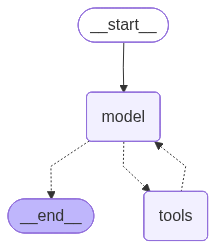

In [49]:
agent

In [51]:
response = agent.invoke({
    "messages": [{"role": "user", "content": "What is Agent Server?"}]
})

print(response)

{'messages': [HumanMessage(content='What is Agent Server?', additional_kwargs={}, response_metadata={}, id='a7040714-05c9-4598-a7d9-38eea5b3fde2'), AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is Agent Server?" Need to explain. Likely refers to LangChain\'s Agent Server? Could be a component in LangChain for hosting agents as a server. Or in general, "Agent Server" could be a term in various contexts. Need to clarify. Might search.', 'tool_calls': [{'id': 'fc_43d1aff5-d03b-41aa-8c6a-61257f8d62bd', 'function': {'arguments': '{"query":"Agent Server"}', 'name': 'langmith-search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 91, 'prompt_tokens': 281, 'total_tokens': 372, 'completion_time': 0.189874583, 'completion_tokens_details': {'reasoning_tokens': 62}, 'prompt_time': 0.012858446, 'prompt_tokens_details': None, 'queue_time': 0.050461634, 'total_time': 0.202733029}, 'model_name': 'openai/gpt-oss-120b', 'system_fing

In [52]:
messages = response["messages"]
final_answer = messages[-1].content

print(final_answer)

**Agent Server – an overview**

Agent Server is a managed‑service component of the **LangChain/LangSmith** ecosystem that lets you **deploy, run, and manage “agent‑based” applications** (also called *assistants*) through a simple, HTTP‑based API.  

Think of it as a *backend‑as‑a‑service* for any workflow that is driven by a language‑model‑powered agent—whether that workflow is a background job, an interactive chatbot, a data‑pipeline orchestrator, or a multi‑agent system that calls external tools.

Below is a concise breakdown of what Agent Server is, how it works, and why you might want to use it.

---

## 1. Core Concept

| Term | Meaning in Agent Server |
|------|--------------------------|
| **Assistant** | A *configured agent* that knows how to handle a specific task (e.g., “order pizza”, “summarize documents”, “run a financial analysis”). An assistant is defined by a **graph** (a LangGraph/LangChain workflow) that encodes the agent’s logic, tool calls, and state transitions. |
|

In [ ]:
1706.03762


In [53]:
agent.invoke({"input":"[1706.03762]"})

{'messages': [AIMessage(content='I’m ready—what would you like to know or discuss today?', additional_kwargs={'reasoning_content': "We need to answer user query. But we haven't seen the user query yet. Let's scroll."}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 272, 'total_tokens': 315, 'completion_time': 0.090785365, 'completion_tokens_details': {'reasoning_tokens': 20}, 'prompt_time': 0.680672903, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.051273117, 'total_time': 0.771458268}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_bc9a6c9b5f', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dc465-311a-72e2-9c5f-6e2b1f916766-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 272, 'output_tokens': 43, 'total_tokens': 315, 'input_token_details': {'cache_read': 256}, 'output_token_details': {'reasoning': 20}})]}

In [55]:
response = agent.invoke({
    "messages": [{"role": "user", 
                  "content": "[1706.03762]"}]
})

In [56]:
response

{'messages': [HumanMessage(content='[1706.03762]', additional_kwargs={}, response_metadata={}, id='dc66cd44-3059-43a6-a28a-d493d9534697'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user gave "[1706.03762]". That\'s an arXiv identifier. They likely want info about the paper, maybe summary. We need to fetch arXiv entry. Use arxiv tool.', 'tool_calls': [{'id': 'fc_fdad8940-da4b-4e8c-85da-b5ac757159ea', 'function': {'arguments': '{"query":"1706.03762"}', 'name': 'arxiv'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 75, 'prompt_tokens': 283, 'total_tokens': 358, 'completion_time': 0.157248815, 'completion_tokens_details': {'reasoning_tokens': 44}, 'prompt_time': 0.500876407, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.050671428, 'total_time': 0.658125222}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_bc9a6c9b5f', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, '